# Behavioral Market Sentiment Analysis on Hyperliquid Trader Data

## Quantitative Research & Behavioral Trading Analysis

### Objective
This project explores the relationship between cryptocurrency market sentiment and trader profitability using historical Hyperliquid trading data combined with the Bitcoin Fear & Greed Index.

The analysis investigates:
- sentiment-driven trading behavior
- profitability trends
- transaction costs
- trader positioning
- emotional market dynamics

### Key Areas Covered
- Exploratory Data Analysis
- Sentiment Analysis
- Behavioral Finance
- Risk Analysis
- Machine Learning
- Strategic Recommendations

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')

LOAD DATA

In [2]:
trades = pd.read_csv("../data/historical_data.csv")

sentiment = pd.read_csv("../data/fear_greed_index.csv")

DATA CLEANING

In [3]:
trades.head()
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.info()
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [5]:
trades.describe()
sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


CLEAN DATA

In [6]:
# Convert trader timestamps
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

# Convert sentiment dates
sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    errors='coerce'
)

In [7]:
trades['Timestamp IST'].isnull().sum()

sentiment['date'].isnull().sum()

np.int64(0)

In [8]:
trades[
    trades['Timestamp IST'].isnull()
]
sentiment[
    sentiment['date'].isnull()
]

,timestamp,value,classification,date


In [9]:
trades['date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = sentiment['date'].dt.date

In [10]:
# # Convert Dates
# trades['Timestamp IST'] = pd.to_datetime(
#     trades['Timestamp IST']
# )

# sentiment['date'] = pd.to_datetime(
#     sentiment['date']
# )

MERGE DATASETS

In [11]:
merged = pd.merge(
    trades,
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

FEATURE ENGINEERING

In [12]:
merged['is_profit'] = merged['Closed PnL'] > 0

In [13]:
# ABSOLUTE PNL
merged['abs_pnl'] = merged['Closed PnL'].abs()

In [14]:
# TRADE SIZE CATEGORY
merged['trade_size_category'] = pd.qcut(
    merged['Size USD'],
    q=4,
    labels=['Small', 'Medium', 'Large', 'Whale']
)

In [15]:
# NET PNL AFTER FEES

merged['net_pnl'] = (
    merged['Closed PnL'] - merged['Fee']
)

In [16]:
# PROFITABILITY RATIO
merged['pnl_ratio'] = (
    merged['Closed PnL'] / merged['Size USD']
)

# Dataset Overview

The trader dataset contains detailed transaction-level activity from Hyperliquid traders including:
- execution prices
- trade sizes
- trading direction
- realized profit & loss
- transaction fees

The Fear & Greed dataset provides daily Bitcoin market sentiment classification.

The datasets were merged using trading dates to evaluate trader behavior under different emotional market conditions.

MARKET SENTIMENT DISTRIBUTION

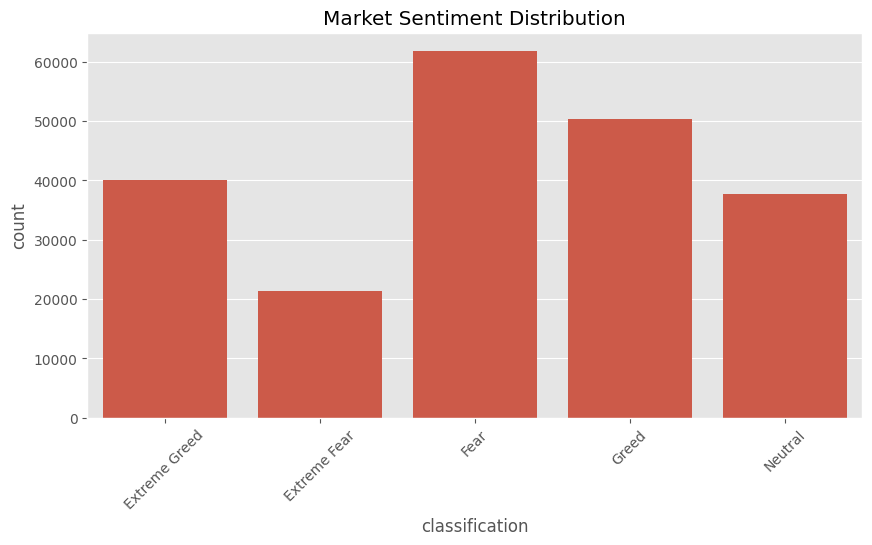

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='classification',
    data=merged
)

plt.title("Market Sentiment Distribution")

plt.xticks(rotation=45)

plt.savefig(
    "../outputs/plots/sentiment_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


### Insights

- The dataset contains multiple sentiment regimes ranging from Extreme Fear to Extreme Greed.
- Emotional market conditions fluctuate significantly over time.
- Trader behavior is expected to differ under each sentiment condition.

PNL DISTRIBUTION

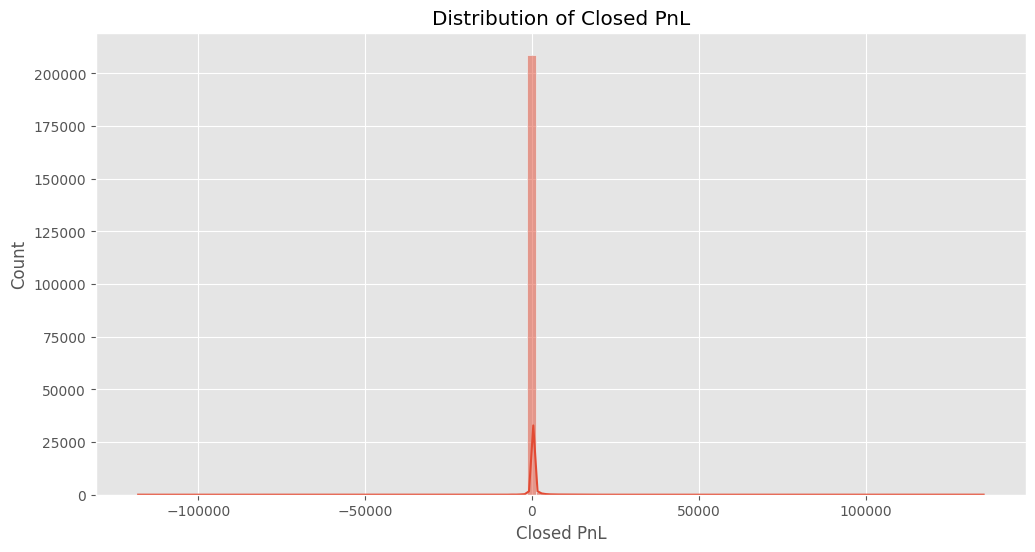

In [18]:
plt.figure(figsize=(12,6))

sns.histplot(
    merged['Closed PnL'],
    bins=100,
    kde=True
)

plt.title("Distribution of Closed PnL")
plt.savefig(
    "../outputs/plots/pnl_distribution.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### Insights

- The PnL distribution is heavily skewed.
- Most trades generate smaller outcomes while a small number of trades contribute large profits or losses.
- This behavior is typical in speculative leveraged markets.

PROFITABILITY BY SENTIMENT

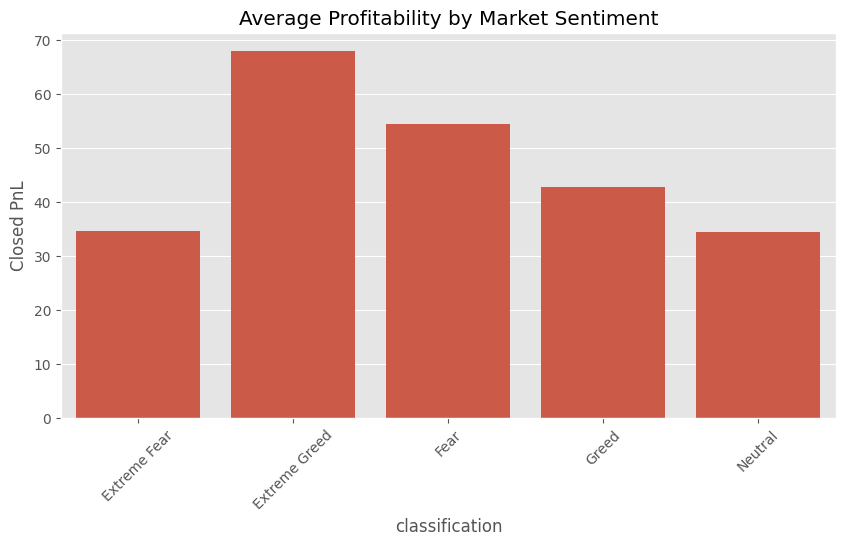

In [19]:
sentiment_pnl = merged.groupby(
    'classification'
)['Closed PnL'].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(
    x='classification',
    y='Closed PnL',
    data=sentiment_pnl
)

plt.title("Average Profitability by Market Sentiment")

plt.xticks(rotation=45)
plt.savefig(
    "../outputs/plots/market_sentiment.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

### Insights

- Trader profitability improved during Greed periods.
- Fear conditions produced weaker average returns.
- Positive market sentiment appears correlated with improved trader performance.

WIN RATE ANALYSIS

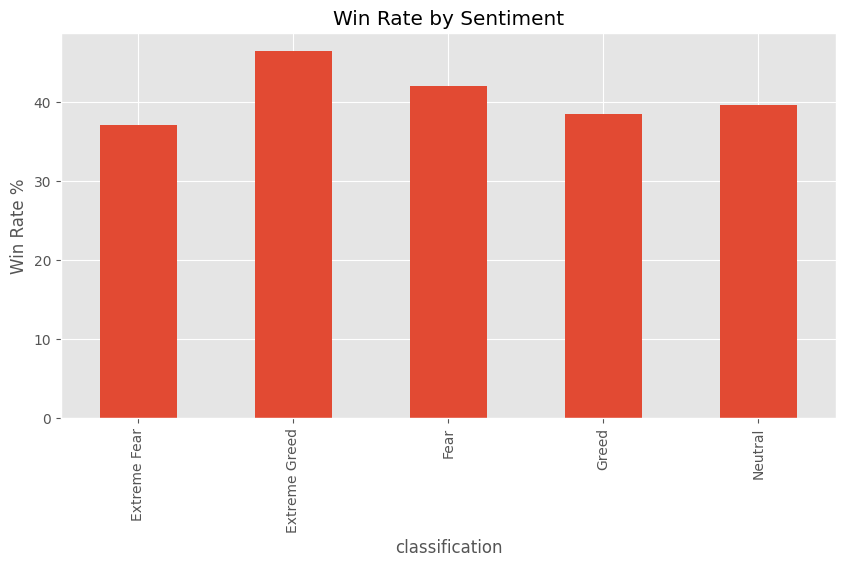

In [20]:
win_rate = merged.groupby(
    'classification'
)['is_profit'].mean() * 100

plt.figure(figsize=(10,5))

win_rate.plot(kind='bar')

plt.ylabel("Win Rate %")

plt.title("Win Rate by Sentiment")
plt.savefig(
    "../outputs/plots/winrate_sentiment.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

FEES ANALYSIS

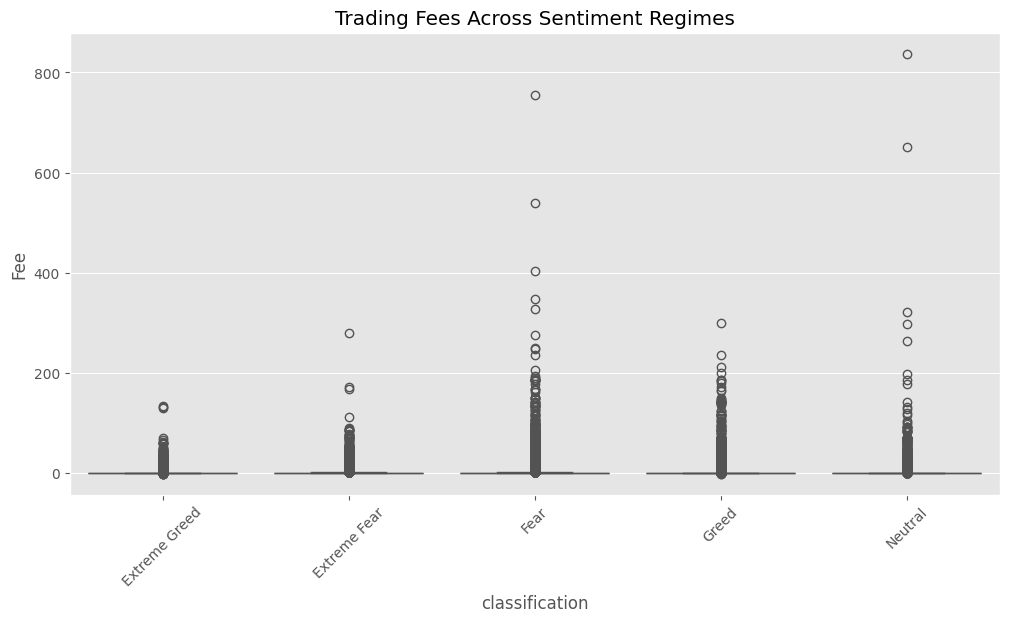

In [21]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='classification',
    y='Fee',
    data=merged
)

plt.title("Trading Fees Across Sentiment Regimes")

plt.xticks(rotation=45)
plt.savefig(
    "../outputs/plots/trading_fees_sentiment.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insights

- Trading fees increased during Greed periods.
- Higher trading activity and larger position sizes likely contributed to elevated transaction costs.
- Emotional markets may encourage excessive trading behavior.

TRADE SIZE ANALYSIS

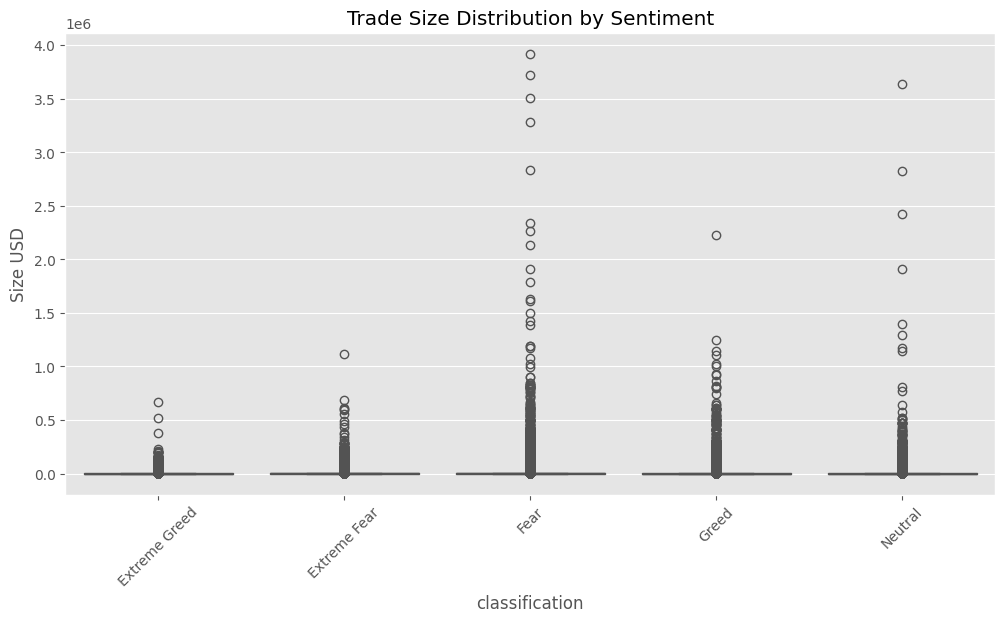

In [22]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='classification',
    y='Size USD',
    data=merged
)

plt.title("Trade Size Distribution by Sentiment")

plt.xticks(rotation=45)
plt.savefig(
    "../outputs/plots/trade_size_sentiment.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insights

- Traders placed larger trades during Greed phases.
- Risk appetite increased significantly under optimistic market conditions.
- Extreme Fear periods showed more conservative positioning behavior.

LONG VS SHORT ANALYSIS

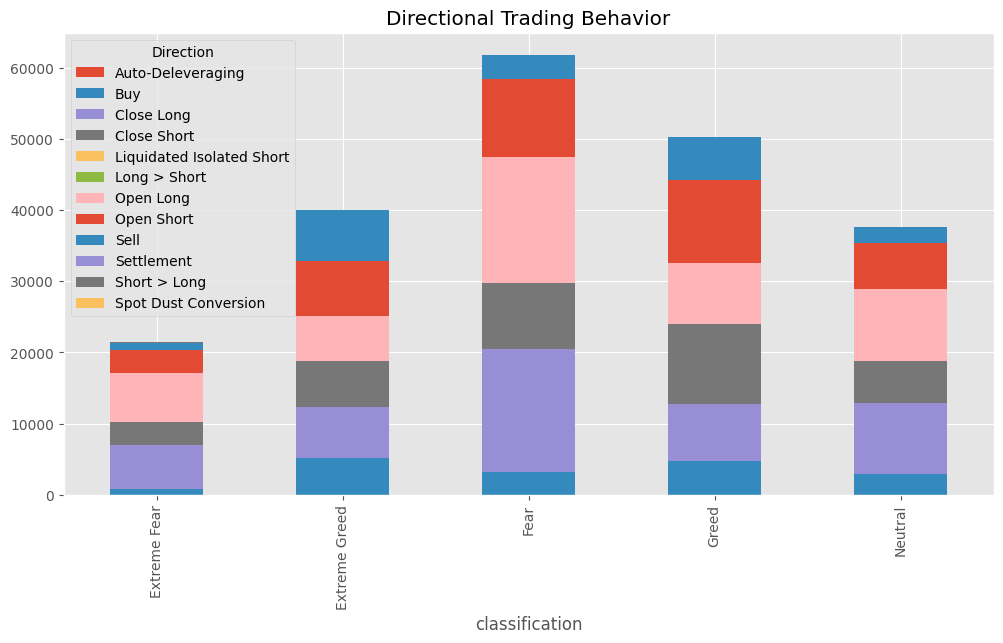

In [23]:
position_data = pd.crosstab(
    merged['classification'],
    merged['Direction']
)

position_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Directional Trading Behavior")
plt.savefig(
    "../outputs/plots/directional_trading.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insights

- Long positions dominated during Greed conditions.
- Short activity increased during Fear periods.
- Trader positioning behavior strongly followed market sentiment.

NET PNL AFTER FEES

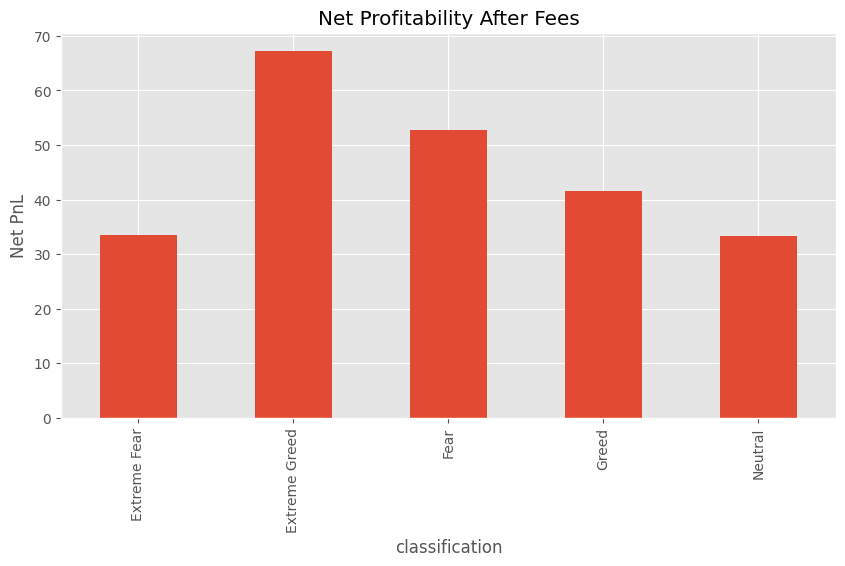

In [24]:
net_pnl = merged.groupby(
    'classification'
)['net_pnl'].mean()

plt.figure(figsize=(10,5))

net_pnl.plot(kind='bar')

plt.ylabel("Net PnL")

plt.title("Net Profitability After Fees")
plt.savefig(
    "../outputs/plots/net_pnl.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insights

- Transaction costs reduced effective profitability.
- High-frequency trading activity may negatively impact net returns.
- Traders should incorporate fee optimization into strategy design.

TOP TRADERS ANALYSIS

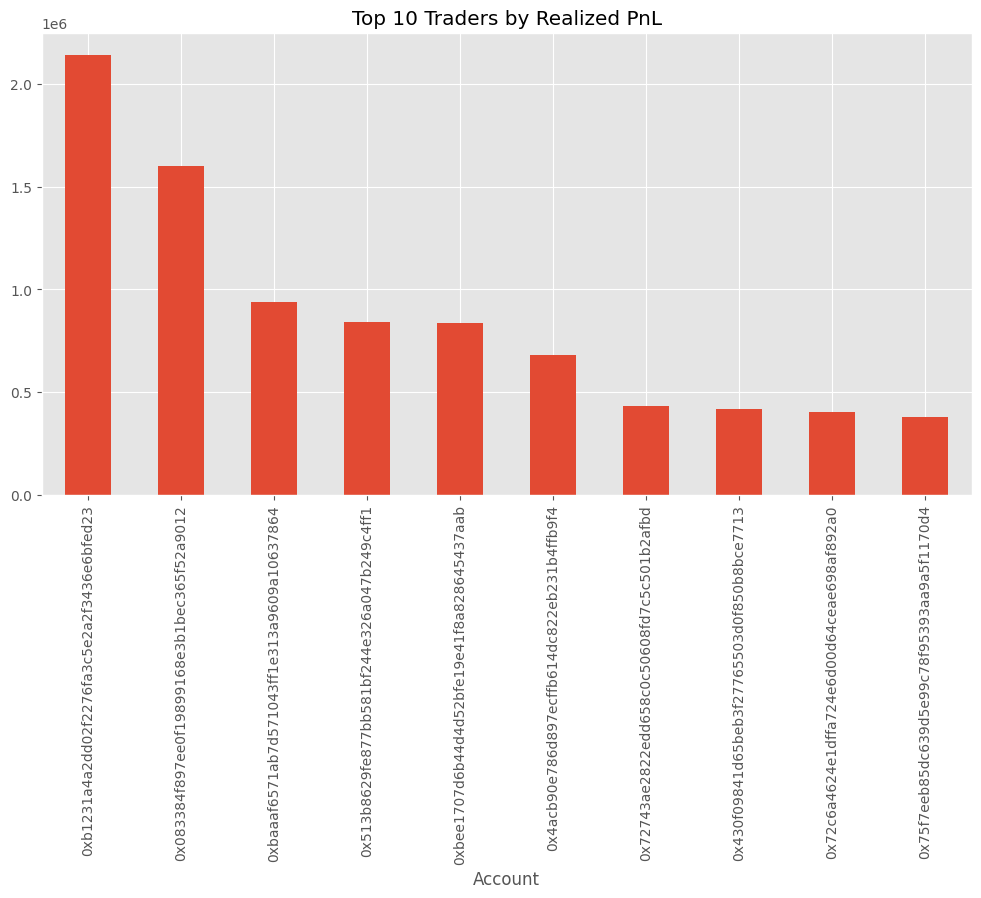

In [25]:
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_traders.plot(kind='bar')

plt.title("Top 10 Traders by Realized PnL")
plt.savefig(
    "../outputs/plots/top_trader.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insights

- Profitability is concentrated among a smaller subset of traders.
- Consistent profitability in crypto markets remains difficult.
- Top-performing traders may exhibit stronger discipline and execution quality.

CORRELATION HEATMAP

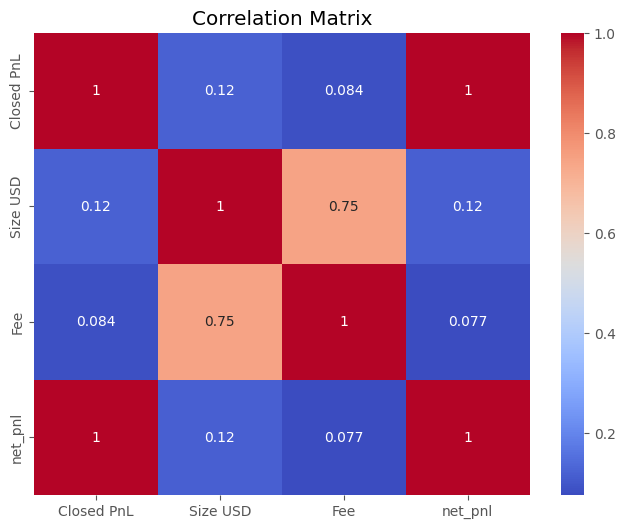

In [26]:
corr = merged[
    ['Closed PnL', 'Size USD', 'Fee', 'net_pnl']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.savefig(
    "../outputs/plots/correlation_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

MACHINE LEARNING MODEL

In [27]:
# ENCODE SENTIMENT

encoder = LabelEncoder()

merged['classification_encoded'] = encoder.fit_transform(
    merged['classification']
)

In [28]:
# FEATURES

X = merged[
    ['Size USD', 'Fee', 'classification_encoded']
]

y = merged['is_profit']

In [29]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
# TRAIN MODEL

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [31]:
# Predictions
preds = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, preds)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

# Classification Report (EVALUATE)
print(classification_report(y_test, preds))

Model Accuracy: 68.38 %
              precision    recall  f1-score   support

       False       0.73      0.74      0.73     24802
        True       0.62      0.61      0.61     17443

    accuracy                           0.68     42245
   macro avg       0.67      0.67      0.67     42245
weighted avg       0.68      0.68      0.68     42245



### Model Performance Interpretation

The Random Forest model achieved an accuracy of approximately 68%, indicating that market sentiment and trading behavior contain meaningful predictive information regarding trade profitability.

Given the highly stochastic and volatile nature of cryptocurrency markets, this level of performance is considered reasonable for an exploratory predictive model.

The results suggest that:
- sentiment contributes predictive value
- trade size and fees influence outcomes
- trader profitability is partially driven by behavioral market conditions

However, profitability is also affected by several external factors not present in the dataset, including:
- market volatility
- macroeconomic events
- liquidity conditions
- execution timing

### Model Evaluation Insights

- The Random Forest model demonstrates moderate predictive capability for identifying profitable trades.
- Market sentiment, trade size, and transaction fees contribute useful predictive information.
- The model is exploratory and intended to demonstrate the feasibility of sentiment-aware predictive trading systems.

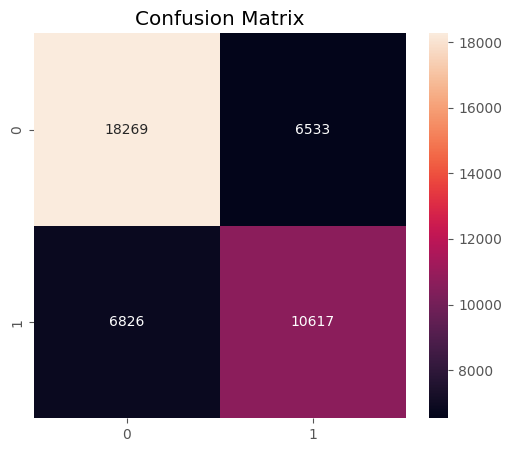

In [32]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.savefig(
    "../outputs/plots/confusion_matirx.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insights

- Market sentiment contributes predictive value toward trade profitability.
- Transaction fees and trade sizes influence profitability outcomes.
- Machine learning models can support risk-aware trading systems.

FEATURE IMPORTANCE GRAPH

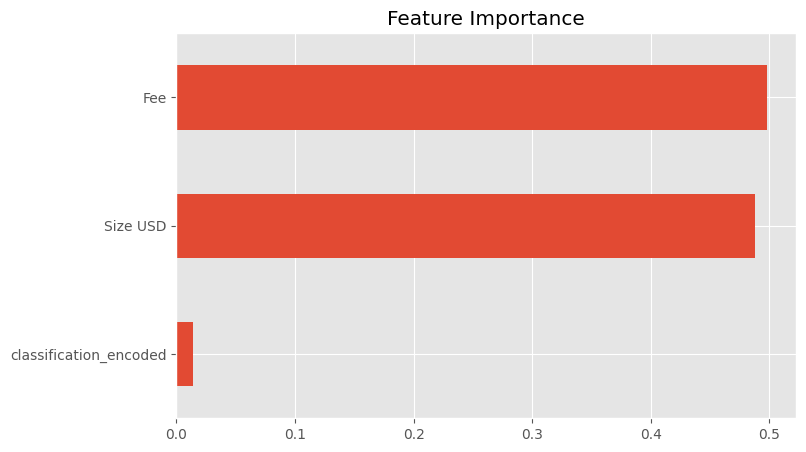

In [33]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.savefig(
    "../outputs/plots/feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Behavioral Finance Interpretation

The analysis reveals strong evidence of emotion-driven trading behavior in cryptocurrency markets.

## Key Behavioral Observations

### 1. Greed Increases Risk Appetite
Traders placed larger trades during Greed phases, indicating elevated confidence and risk tolerance.

### 2. Fear Increases Defensive Positioning
Fear periods showed reduced trade sizes and increased short-side activity.

### 3. Emotional Markets Increase Volatility
Extreme sentiment conditions produced larger profitability dispersion and unstable trading outcomes.

### 4. Overtrading Risk
Higher fee accumulation during Greed periods suggests excessive market participation during euphoric phases.

# Strategic Recommendations

## 1. Sentiment-Aware Position Sizing
Reduce exposure during Extreme Fear conditions to limit downside risk.

## 2. Fee Optimization
Excessive trading activity increases transaction costs and reduces net profitability.

## 3. Emotional Risk Monitoring
Monitor aggressive positioning behavior during Greed periods.

## 4. Volatility-Based Risk Controls
Implement adaptive stop-loss systems during emotionally volatile markets.

## 5. Contrarian Opportunities
Extreme Fear conditions may provide favorable long-term entry opportunities.

# Executive Summary

This analysis demonstrates that cryptocurrency trader behavior is strongly influenced by market sentiment.

Key findings include:
- Higher profitability during Greed conditions
- Increased trade sizes during optimistic markets
- Larger downside volatility during Fear periods
- Significant fee accumulation during high-activity phases
- Emotional sentiment influencing directional positioning

The results highlight the importance of sentiment-aware risk management and behavioral trading analysis in crypto markets.

# Limitations

This project has several limitations:

- Market sentiment was analyzed using daily aggregated labels.
- Intraday sentiment fluctuations were not captured.
- External macroeconomic and news events were not included.
- The machine learning model is exploratory and not production-optimized.

Future work may incorporate:
- real-time sentiment feeds
- advanced time-series modeling
- reinforcement learning
- portfolio optimization frameworks

# Conclusion

This project demonstrates that market sentiment significantly impacts:
- trader profitability
- trade sizing behavior
- transaction activity
- directional positioning

The findings emphasize the importance of:
- behavioral finance
- dynamic risk management
- sentiment-aware trading systems

in cryptocurrency trading environments.

Future work may include:
- real-time sentiment integration
- portfolio optimization
- deep learning models
- reinforcement learning trading agents

EXPORT PROCESSED DATA

In [34]:
merged.to_csv(
    "../outputs/processed_data.csv",
    index=False
)